In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname, "→", len(filenames), "files")

/kaggle/input → 0 files
/kaggle/input/datasets → 0 files
/kaggle/input/datasets/kmader → 0 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000 → 5 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1 → 5000 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1 → 5000 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2 → 5015 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_2 → 5015 files


In [2]:
import pandas as pd

# Load metadata
df = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['dx'].value_counts())
print("\nClass percentages:")
print(df['dx'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Dataset shape: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Class percentages:
dx
nv       66.95%
mel      11.11%
bkl      10.97%
bcc       5.13%
akiec     3.27%
vasc      1.42%
df        1.15%
Name: proportion, dtype: object


/tmp/ipykernel_58/701630253.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)


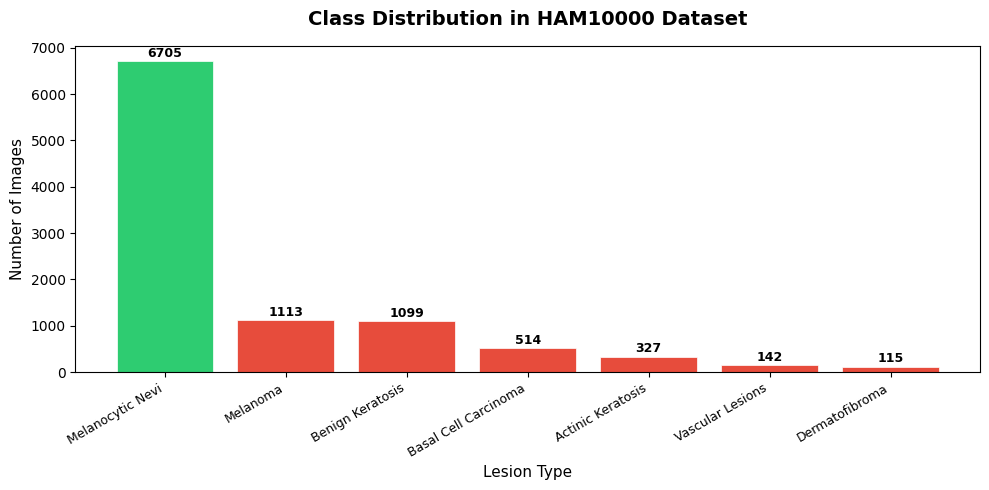

Chart saved.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Full class names for readability
class_names = {
    'nv': 'Melanocytic Nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'vasc': 'Vascular Lesions',
    'df': 'Dermatofibroma'
}

counts = df['dx'].value_counts()
labels = [class_names[c] for c in counts.index]
colors = ['#2ecc71' if c == 'nv' else '#e74c3c' for c in counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('Class Distribution in HAM10000 Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Lesion Type', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [4]:
import os
import numpy as np
from PIL import Image

# Build a combined image path lookup
image_dir_1 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
image_dir_2 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'

# Map image_id to full path
image_paths = {}
for fname in os.listdir(image_dir_1):
    image_paths[fname.replace('.jpg', '')] = os.path.join(image_dir_1, fname)
for fname in os.listdir(image_dir_2):
    image_paths[fname.replace('.jpg', '')] = os.path.join(image_dir_2, fname)

print(f"Total images indexed: {len(image_paths)}")

Total images indexed: 10015


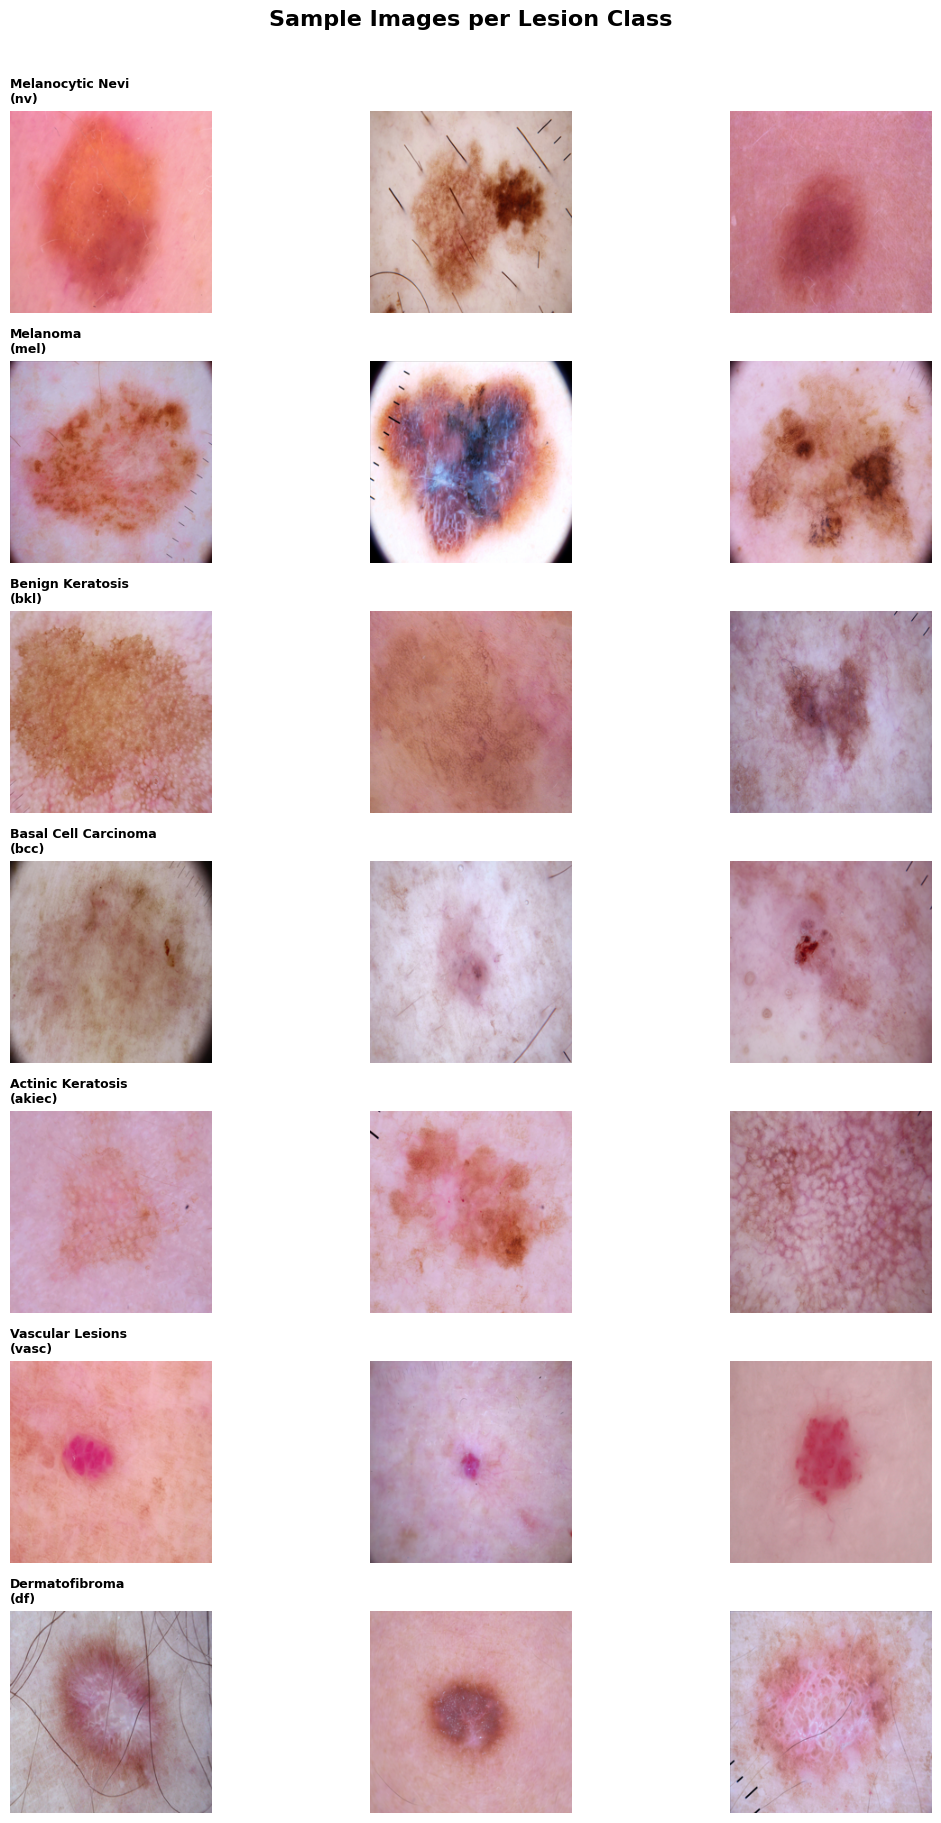

Sample images saved.


In [5]:
fig, axes = plt.subplots(7, 3, figsize=(12, 18))
fig.suptitle('Sample Images per Lesion Class', fontsize=16, fontweight='bold', y=1.01)

for row_idx, (code, name) in enumerate(class_names.items()):
    # Get 3 sample image IDs for this class
    samples = df[df['dx'] == code]['image_id'].sample(3, random_state=42).values
    
    for col_idx, img_id in enumerate(samples):
        img_path = image_paths.get(img_id)
        img = Image.open(img_path).resize((224, 224))
        
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(f'{name}\n({code})', 
                                              fontsize=9, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('sample_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved.")